<a href="https://colab.research.google.com/github/ravi-soda/Calculator-based-mac/blob/master/Lecture_1_tutorial_classification_task_tutorial_and_DIY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction using scikit-learn #

![breast cancer detection image](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-57740-5/MediaObjects/41598_2024_57740_Fig1_HTML.png)

Problem - Breast cancer prediction is a binary classification problem where the goal is to determine whether a tumor is malignant (cancerous) or benign (non-cancerous) based on measurable characteristics of cell nuclei obtained from medical imaging or biopsies.


sklearn datasets - https://scikit-learn.org/stable/api/sklearn.datasets.html

## Import required libraries ##

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading the breast cancer data ##

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data #loads the 30 features av in the dataset
y = data.target #class (benign/malignant)

print("Shape:", X.shape) #569 is the sample count

Shape: (569, 30)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) #80/20 split of data for training and testing
#randomly sampke the entire set and then divide
#intoi the two groups test /train
#random state ensures that evry time same
#type of randomness is induced to split

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Part-1 : Classification using Logistic Regression ##

In [ ]:
from sklearn.linear_model import LogisticRegression
#for classification
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test) #for prediction test phase


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support


Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



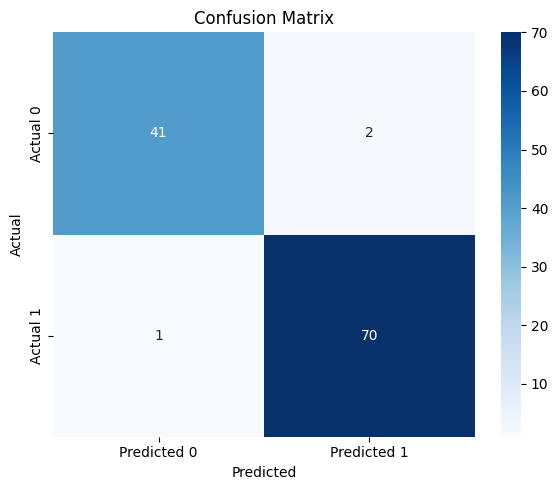

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Do-It-Yourself (DIY) ##

So far, we explored Logistic Regression. It assumes linear decision boundary and simple relationships.

But real-world data is often Non-linear, Noisy and Complex

This raises a question: Can we build better classifiers using other algorithms?

## Part - 2 (DIY) ##

Lets explore how we can implement the other ML Classification algorithms, namely

  1. K-Nearest Neighbors - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
  2. Decision Tree Classifier - https://scikit-learn.org/stable/modules/tree.html
  3. Support Vector Machines - https://scikit-learn.org/stable/modules/svm.html




## Part - 2a : KNN ##

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="euclidean"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
# TODO: Train model
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='distance')

In [ ]:
# TODO: Predict and evaluate
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_iris()

X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean'
)

# Train model
knn.fit(X_train, y_train)

# Predict test data
y_pred = knn.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



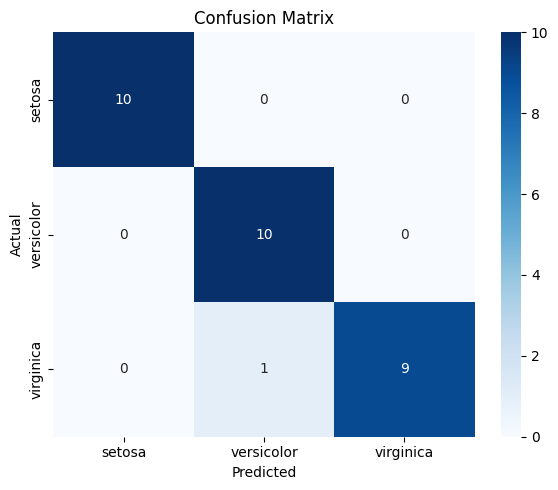

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean'
)

knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Part - 2b : Decision Tree Classifier ##

In [ ]:
# TODO: Import Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# TODO: Train model
y_pred = dt.predict(X_test)

In [ ]:
# TODO: Predict and evaluate

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



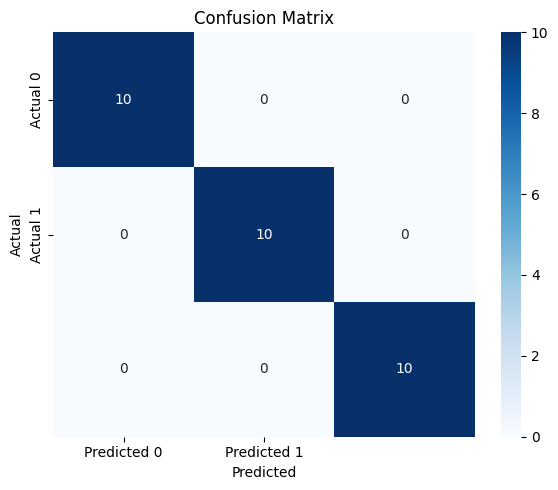

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Part - 2c : SVM ##

In [ ]:
# TODO: Import SVM

from sklearn.svm import SVC  # For classification

svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [ ]:
# TODO: Train model
y_pred = svm.predict(X_test)

In [ ]:
# TODO: Predict and evaluate

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support

Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



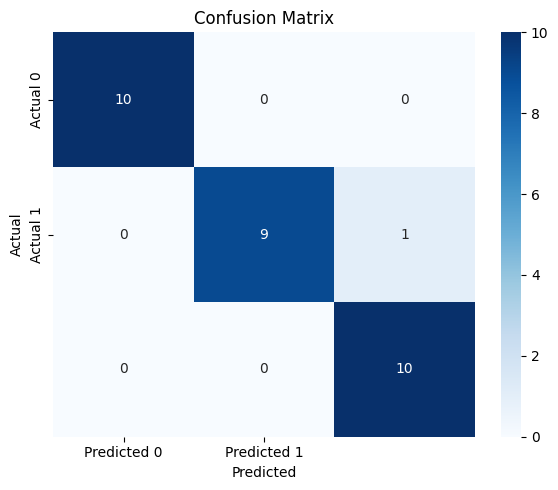

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()